# **TaniMol: 03 - Tanimoto Similarity**

This notebook loads the generated fingerprints from `02_fingerprints` and calculates pairwise Tanimoto similarity matrices. These matrices represent the structural similarity between every pair of molecules in our dataset.

**Input:** `.npy` fingerprint files from `data/processed/fingerprints/`  
**Output:** Tanimoto similarity matrices ready for downstream analysis (clustering)

In [1]:
import numpy as np

from src.config import MORGAN_FP_PATH, MACCS_FP_PATH, RDKIT_FP_PATH
from src.config import MORGAN_SIM_PATH, MACCS_SIM_PATH, RDKIT_SIM_PATH
from src.fingerprints import load_fingerprints
from src.similarity import calculate_similarity_matrix, save_similarity_matrix

### **1. Load Fingerprints**

Load the pre-calculated binary vectors for Morgan, MACCS, and RDKit topological fingerprints.

In [2]:
morgan_fps = load_fingerprints(MORGAN_FP_PATH)
maccs_fps = load_fingerprints(MACCS_FP_PATH)
rdkit_fps = load_fingerprints(RDKIT_FP_PATH)

### **2. Calculate Similarity Matrices**

Calculate the pairwise Tanimoto (Jaccard) similarity for all 11k+ molecules. Since $N \approx 11000$, the resulting matrix will be roughly $11000 \times 11000$ elements (approx. 121 million pairs).

*Note: This calculation uses optimized SciPy routines and should complete in seconds.*

### **A. Morgan**

In [3]:
%%time
morgan_sim_matrix = calculate_similarity_matrix(morgan_fps)

CPU times: user 3.67 s, sys: 186 ms, total: 3.85 s
Wall time: 677 ms


### **B. MACCS**

In [4]:
%%time
maccs_sim_matrix = calculate_similarity_matrix(maccs_fps)

CPU times: user 1.44 s, sys: 164 ms, total: 1.6 s
Wall time: 324 ms


### **C. RDKit**

In [5]:
%%time
rdkit_sim_matrix = calculate_similarity_matrix(rdkit_fps)

CPU times: user 3.39 s, sys: 150 ms, total: 3.54 s
Wall time: 654 ms


### **3. Sanity Checks**

Verify the shape and properties of the resulting matrices. 
- Shape should be `(N, N)`
- The diagonal should be exactly `1.0` (each molecule is 100% similar to itself)
- The matrix must be symmetric

In [6]:
def check_matrix(matrix, name):
    print(f"--- {name} ---")
    print(f"Shape: {matrix.shape}")
    
    diag_mean = np.mean(np.diag(matrix))
    print(f"Diagonal elements mean: {diag_mean:.4f} (expected 1.0)")
    
    is_symmetric = np.allclose(matrix, matrix.T)
    print(f"Is symmetric: {is_symmetric}")

check_matrix(morgan_sim_matrix, "Morgan Matrix")
check_matrix(maccs_sim_matrix, "MACCS Matrix")
check_matrix(rdkit_sim_matrix, "RDKit Matrix")

--- Morgan Matrix ---
Shape: (11012, 11012)
Diagonal elements mean: 1.0000 (expected 1.0)
Is symmetric: True
--- MACCS Matrix ---
Shape: (11012, 11012)
Diagonal elements mean: 1.0000 (expected 1.0)
Is symmetric: True
--- RDKit Matrix ---
Shape: (11012, 11012)
Diagonal elements mean: 1.0000 (expected 1.0)
Is symmetric: True


### **4. Visualize Similarity Heatmap**

Visualizing a subset of the similarity matrix to identify potential clusters of structurally similar compounds. Plotting the full 11k x 11k matrix would be computationally expensive for the display, so we sample a subset of 500 molecules.


[Morgan] Computing linkage for 11,012 molecules...
[Morgan] Done. Reordering matrix...


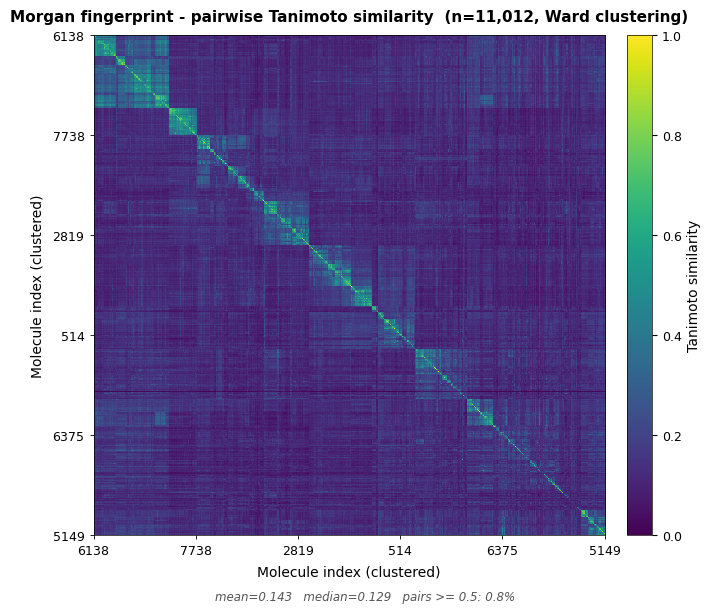

[MACCS] Computing linkage for 11,012 molecules...
[MACCS] Done. Reordering matrix...


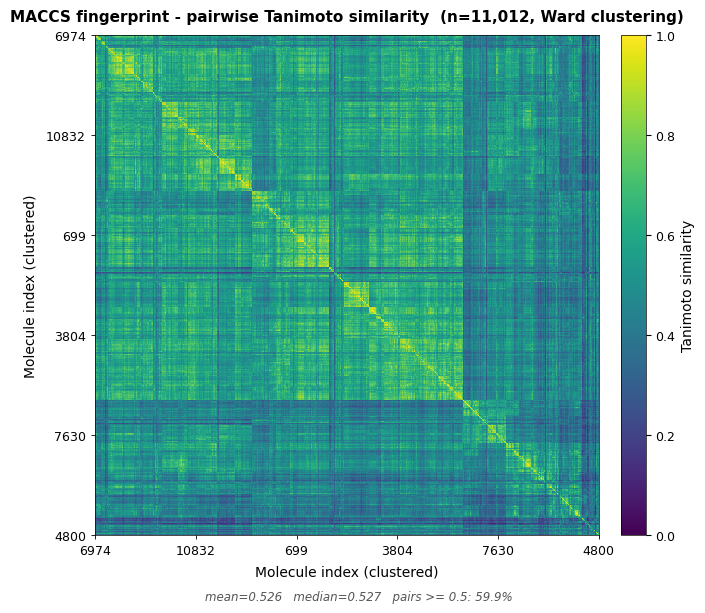

[RDKit] Computing linkage for 11,012 molecules...
[RDKit] Done. Reordering matrix...


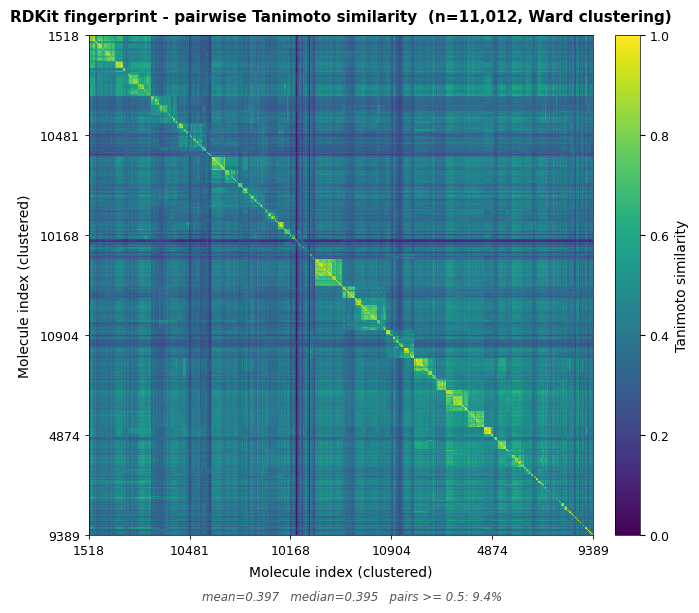

In [7]:
# Komórka w Notebooku:
from src.visualization import plot_similarity_heatmap

order_morgan = plot_similarity_heatmap(morgan_sim_matrix, "Morgan")
order_maccs  = plot_similarity_heatmap(maccs_sim_matrix,  "MACCS")
order_rdkit  = plot_similarity_heatmap(rdkit_sim_matrix,  "RDKit")

### **5. Save Similarity Matrices**

Save the computed dense Tanimoto similarity matrices to `data/processed/similarity/` as `.npy` files. These high-dimensional arrays will be loaded in the next step to perform Butina clustering without needing to recalculate the 121 million pairwise comparisons.


In [8]:
save_similarity_matrix(morgan_sim_matrix, MORGAN_SIM_PATH)
save_similarity_matrix(maccs_sim_matrix, MACCS_SIM_PATH)
save_similarity_matrix(rdkit_sim_matrix, RDKIT_SIM_PATH)

Saved 11012x11012 similarity matrix to /home/stanuch/Dev/TaniMol/data/processed/similarity/morgan_sim.npy
Saved 11012x11012 similarity matrix to /home/stanuch/Dev/TaniMol/data/processed/similarity/maccs_sim.npy
Saved 11012x11012 similarity matrix to /home/stanuch/Dev/TaniMol/data/processed/similarity/rdkit_sim.npy
